In [1]:
import os
import sys
from pathlib import Path

ROOT = Path.cwd().parent.resolve()

if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

if Path.cwd() != ROOT:
    os.chdir(ROOT)

In [2]:
import cv2
from IPython.display import clear_output, display, update_display, HTML
import matplotlib.animation as animation
import matplotlib.pyplot as plt
import numpy as np
import torch
from torchmetrics.image import PeakSignalNoiseRatio, StructuralSimilarityIndexMeasure
from torchmetrics.image.lpip import LearnedPerceptualImagePatchSimilarity
import torchvision
from torchvision.transforms import v2

from src.depth import get_target_depth
from src.strokegs import strokegs
from src.stroke_optimizer import stroke_optimization_stream

ninja: no work to do.


Parameters:

- `n_strokes`: number of strokes to optimize
- `n_iters`: number of optimization iterations (must be >= `stroke_reset_until_iter`)
- `stroke_reset_interval`: interval (in iterations) to reset strokes of low contribution
- `stroke_reset_until_iter`: stroke resets stop after this iteration

View all parameters in the [config file](../configs/config.yaml).


In [3]:
img_dir = "assets"
img_path = Path(img_dir) / "0808.png"

# optimization parameters
n_strokes = 2048
n_iters = 4000
stroke_reset_interval = 250
stroke_reset_until_iter = 2000


# render
dpi = 75
scale = 1.0
frame_interval = 5

In [4]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cuda


Image resolution: 1356 x 2040


Loading weights:   0%|          | 0/287 [00:00<?, ?it/s]

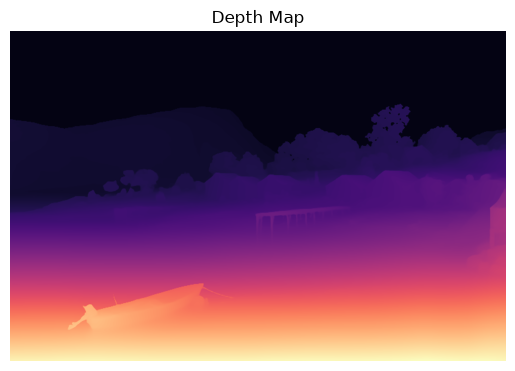

In [5]:
img_tensor = torchvision.io.read_image(str(img_path)).unsqueeze(0)

transforms = [
    v2.ToImage(),
    v2.ToDtype(torch.float32, scale=True),
]


transform = v2.Compose(transforms)
img_tensor = transform(img_tensor).to(device)

_, _, H, W = img_tensor.shape
background = torch.zeros(1, 4, H, W, device=device)
print(f"Image resolution: {H} x {W}")


img_np = (img_tensor * 255).permute(0, 2, 3, 1).cpu().numpy()
target_depth_map = get_target_depth(img_np)
depth = target_depth_map.squeeze().cpu().numpy()

plt.imshow(depth, cmap="magma")
plt.title("Depth Map")
plt.axis("off")
plt.show()

In [6]:
def resize_to_max_edge(img, max_edge=512):
    h, w = img.shape[:2]
    if max(h, w) <= max_edge:
        return img

    if h > w:
        new_h = max_edge
        new_w = int(w * (max_edge / h))
    else:
        new_w = max_edge
        new_h = int(h * (max_edge / w))

    return cv2.resize(img, (new_w, new_h), interpolation=cv2.INTER_AREA).clip(0.0, 1.0)


# resize image for display only
small_img = resize_to_max_edge(img_tensor.squeeze(0).permute(1, 2, 0).cpu().numpy())
H_small, W_small = small_img.shape[:2]

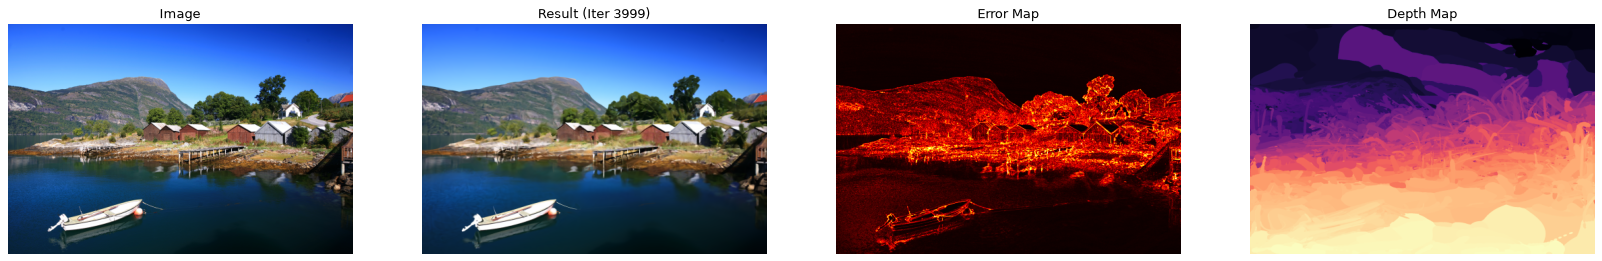

In [7]:
gen = stroke_optimization_stream(
    target_img=img_tensor,
    background=background,
    n_strokes=n_strokes,
    n_iters=n_iters,
    stroke_reset_interval=stroke_reset_interval,
    stroke_reset_until_iter=stroke_reset_until_iter,
)


fig, (ax1, ax2, ax3, ax4) = plt.subplots(
    1, 4, figsize=(4 * W_small / dpi * scale, H_small / dpi * scale), dpi=dpi
)
im1 = ax1.imshow(small_img)
im2 = None
im3 = None
im4 = None
ax1.axis("off")
ax1.set_title("Image")
ax3.set_title(f"Error Map")
ax4.set_title(f"Depth Map")
plt.rcParams["axes.titlesize"] = 12

for i, step in enumerate(gen):
    if step["type"] == "iter":
        rendered_img = resize_to_max_edge(
            step["rendered_img"][0].permute(1, 2, 0).cpu().numpy()
        )
        error_map = resize_to_max_edge(step["error_map"][0, 0].cpu().numpy())
        depth_map = resize_to_max_edge(step["depth_map"][0].cpu().numpy())

        if im2 is None:
            im2 = ax2.imshow(rendered_img)
            ax2.axis("off")
        else:
            im2.set_data(rendered_img)
        ax2.set_title(f"Result (Iter {step['iter']})")

        if im3 is None:
            im3 = ax3.imshow(error_map, cmap="hot")
            ax3.axis("off")
        else:
            im3.set_data(error_map)

        if im4 is None:
            im4 = ax4.imshow(-depth_map, cmap="magma")
            ax4.axis("off")
        else:
            im4.set_data(-depth_map)

        if i == 0:
            clear_output(wait=True)
            display(fig, display_id="fig")
        else:
            update_display(fig, display_id="fig")
    else:
        history = step["history"]
        best_strokes = step["best_strokes"]
        best_metrics = step["best_metrics"]
        best_iter = step["best_iter"]


clear_output(wait=False)
display(fig)
plt.close(fig)

In [8]:
psnr = PeakSignalNoiseRatio(data_range=1.0).to(device)
ssim = StructuralSimilarityIndexMeasure(data_range=1.0).to(device)
lpips = LearnedPerceptualImagePatchSimilarity(net_type="alex").to(device)

rendered_img, _, _, _ = torch.ops.strokegs.rasterize(best_strokes, background)
result_img = rendered_img[:, :3]  # (1, 3, H, W)

# LPIPS expects image tensors in the range [-1, 1]
pred_lpips = result_img * 2.0 - 1.0
target_lpips = img_tensor * 2.0 - 1.0

with torch.no_grad():
    psnr_val = psnr(result_img, img_tensor).item()
    ssim_val = ssim(result_img, img_tensor).item()
    lpips_val = lpips(pred_lpips, target_lpips).item()

print(
    f"PSNR↑: {psnr_val:.4f} | " f"SSIM↑: {ssim_val:.4f} | " f"LPIPS↓: {lpips_val:.4f}"
)

PSNR↑: 24.2374 | SSIM↑: 0.7237 | LPIPS↓: 0.3950


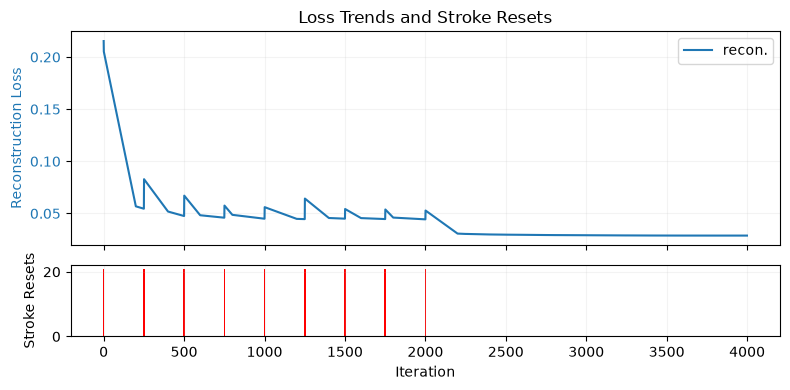

Number of strokes: 2048 | Iterations: 4000
Best loss (iter 3999):
l_recon: 0.028771
Total stroke resets: 189



In [9]:
eps = 1e-6
iters = np.array(history["iter"])

fig, (ax1, ax2) = plt.subplots(
    2, 1, figsize=(8, 4), sharex=True, gridspec_kw={"height_ratios": [3, 1]}
)

ax1.set_title("Loss Trends and Stroke Resets")
(line1,) = ax1.plot(
    iters,
    history["l_recon"],
    label="recon.",
    color="tab:blue",
    linewidth=1.5,
)
ax1.set_ylabel("Reconstruction Loss", color="tab:blue")
ax1.tick_params(axis="y", labelcolor="tab:blue")
ax1.legend(loc="upper right")
ax1.grid(True, which="both", alpha=0.15)


# bottom plot
resets = history["batch_num_reset_strokes"]

ax2.bar(iters, resets, color="red", width=10.0)
ax2.set_ylabel("Stroke Resets")
ax2.set_xlabel("Iteration")
ax2.grid(True, alpha=0.15)

plt.tight_layout()
plt.show()

print(f"Number of strokes: {best_strokes.shape[1]} | Iterations: {n_iters}")
print(f"Best loss (iter {best_iter}):")
for k, v in best_metrics.items():
    if not k == "l_recon":
        continue
    print(f"{k}: {v:.6f}")

print(f"Total stroke resets: {np.sum(resets)}\n")

In [10]:
OUTPUT_DIR = ROOT / "output"
OUTPUT_DIR.mkdir(exist_ok=True)
path = OUTPUT_DIR / f"result_{img_path.stem}.png"
plt.imsave(path, result_img[0].permute(1, 2, 0).cpu().numpy())
print(f"Result saved to: {path.relative_to(ROOT)}")

Result saved to: output/result_0808.png


In [11]:
fps = 60

frames = [resize_to_max_edge(background[0, :3].permute(1, 2, 0).cpu().numpy())]
indices = list(range(best_strokes.shape[1] - 1, 0, -frame_interval))
indices.append(0)

for i in indices:
    rendered_img, _, _, _ = torch.ops.strokegs.rasterize(
        best_strokes[:, i:], background
    )
    frame = resize_to_max_edge(rendered_img[0, :3].permute(1, 2, 0).cpu().numpy())
    frames.append(frame)


fig, (ax_target, ax_result, ax_process) = plt.subplots(
    1, 3, figsize=(3 * W_small / dpi * scale, H_small / dpi * scale), dpi=dpi
)
fig.subplots_adjust(top=0.80)

ax_target.imshow(small_img)
ax_target.set_title("Image")
ax_target.axis("off")

ax_result.imshow(frames[-1])
ax_result.set_title("Result")
ax_result.axis("off")

im = ax_process.imshow(frames[0])
ax_process.set_title("Back-to-front Composition")
ax_process.axis("off")

plt.tight_layout()


def update(frame):
    im.set_array(frame)
    return [im]


anim = animation.FuncAnimation(
    fig, update, frames=frames, interval=1000.0 / fps, blit=True, repeat=False
)

print(f"dpi: {dpi}, scale: {scale}, frame_interval: {frame_interval}, fps: {fps}")
display(HTML(anim.to_html5_video()))
plt.close(fig)

dpi: 75, scale: 1.0, frame_interval: 5, fps: 60
